In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import torch
import torch.nn as nn
import torch.optim as optim
from matplotlib.animation import FuncAnimation
import time
import sympy

In [2]:
T   = 100.0

Nt = 1000

tau = 1.0

a = 0.3
b = 1.05
epsi = 0.05
I = 0.23

## Runge-Kutta

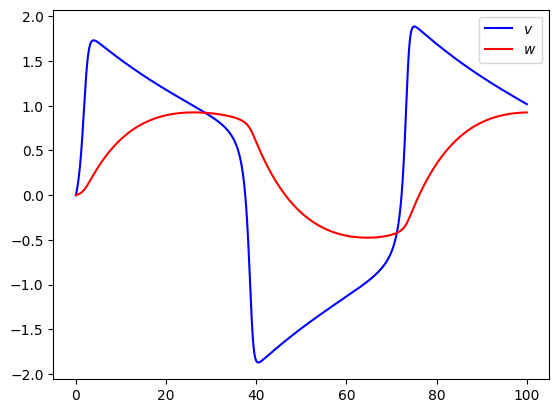

In [48]:
def f_FitzHugh_Nagumo(t,v,w):
  dv = (v - v**3/3.0 - w + I)
  dw = epsi * (v + a - b*w)
  return [dv,dw]

t_rk = np.linspace(0,T,Nt*10)
v_rk = np.zeros(Nt*10)
w_rk = np.zeros(Nt*10)

dt = T/(Nt*10)

for id_t, val_t in enumerate(t_rk[:-1]):
  k1 = f_FitzHugh_Nagumo(val_t, v_rk[id_t], w_rk[id_t])
  k2 = f_FitzHugh_Nagumo(val_t + dt/2, v_rk[id_t] + dt*k1[0]/2, w_rk[id_t] + dt*k1[1]/2)
  k3 = f_FitzHugh_Nagumo(val_t + dt/2, v_rk[id_t] + dt*k2[0]/2, w_rk[id_t] + dt*k2[1]/2)
  k4 = f_FitzHugh_Nagumo(val_t + dt, v_rk[id_t] + dt*k3[0], w_rk[id_t] + dt*k3[1])

  v_rk[id_t+1] = v_rk[id_t] + dt/6 * (k1[0] + 2*k2[0] + 2*k3[0] + k4[0])
  w_rk[id_t+1] = w_rk[id_t] + dt/6 * (k1[1] + 2*k2[1] + 2*k3[1] + k4[1])


plt.plot(t_rk, v_rk,"-b",label = r"$v$")
plt.plot(t_rk, w_rk,"-r",label = r"$w$")
plt.legend()
plt.show()

## PINN

CUDA disponible. Usando GPU para entrenamiento.

  VENTANA 1/10  |  t ∈ [0.0, 10.0]
  Condición inicial: v0=0.000000, w0=0.000000
  [ventana 0] iter     0 | loss=3.083e-02  ODE=3.083e-02  IC=0.000e+00
  [ventana 0] iter  1000 | loss=2.978e-02  ODE=2.553e-02  IC=4.253e-03
  [ventana 0] iter  2000 | loss=4.493e-02  ODE=2.493e-02  IC=2.000e-02
  [ventana 0] iter  3000 | loss=2.987e-02  ODE=2.176e-02  IC=8.105e-03
  [ventana 0] iter  4000 | loss=1.509e-02  ODE=1.447e-02  IC=6.214e-04
  [ventana 0] iter  5000 | loss=4.065e-02  ODE=2.471e-02  IC=1.594e-02
  [ventana 0] iter  6000 | loss=9.749e-03  ODE=7.410e-03  IC=2.339e-03
  [ventana 0] iter  7000 | loss=1.034e-03  ODE=9.771e-04  IC=5.696e-05
  [ventana 0] Convergió en 8000 iters (loss=3.917e-04)

  VENTANA 2/10  |  t ∈ [10.0, 20.0]
  Condición inicial: v0=1.511922, w0=0.626121
  [ventana 1] iter     0 | loss=3.047e+00  ODE=3.116e-02  IC=3.015e+00
  [ventana 1] iter  1000 | loss=3.825e-02  ODE=2.517e-02  IC=1.308e-02
  [ventana 1] iter  20

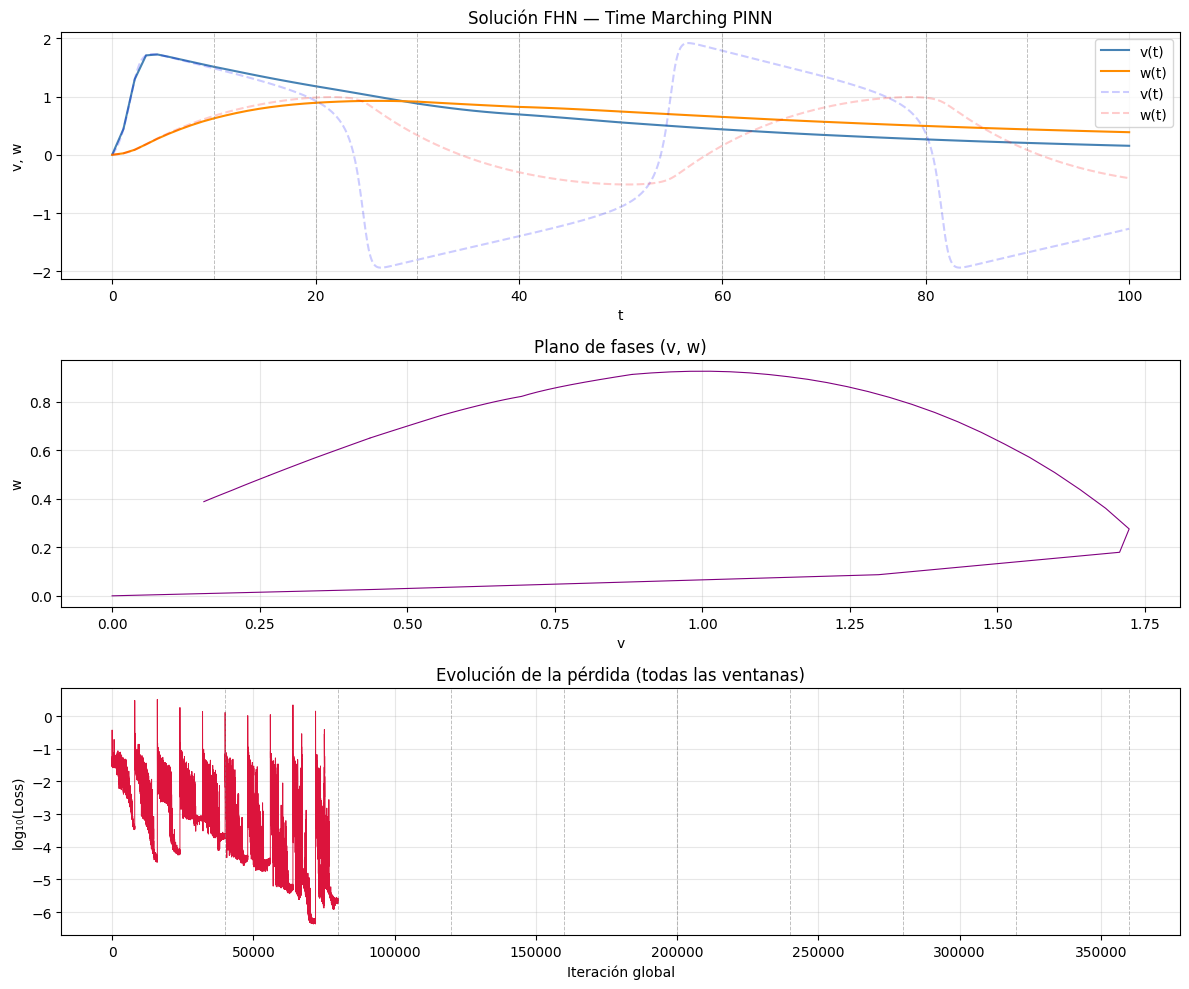

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import time

# =====================================================================
# 1. CONFIGURACIÓN DE GPU/CUDA
# =====================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    print("CUDA disponible. Usando GPU para entrenamiento.")
else:
    print("CUDA no disponible. Usando CPU para entrenamiento.")

# =====================================================================
# 2. PARÁMETROS DEL DOMINIO Y TIME MARCHING
# =====================================================================
ACTIVATION_TYPE = 'tanh'

#T        = 100.0   # tiempo total
DT       = 10.0    # ancho de cada ventana  →  M = T / DT ventanas
M        = int(T / DT)

Nt       = 1000    # puntos de evaluación por ventana (para visualización)



# =====================================================================
# 3. FUNCIONES DE ACTIVACIÓN Y MODELO
# =====================================================================
class SinActivation(nn.Module):
    def forward(self, x):
        return torch.sin(x)

class LorentzianActivation(nn.Module):
    def forward(self, x):
        return 1.0 / (x ** 2 + 1.0)

def get_activation():
    if ACTIVATION_TYPE == 'sin':
        return SinActivation()
    elif ACTIVATION_TYPE == 'sigmoid':
        return nn.Sigmoid()
    elif ACTIVATION_TYPE == 'tanh':
        return nn.Tanh()
    elif ACTIVATION_TYPE == 'SiLU':
        return nn.SiLU()
    elif ACTIVATION_TYPE == 'lorentzian':
        return LorentzianActivation()
    else:
        raise ValueError(f"Función de activación no reconocida: {ACTIVATION_TYPE}")


class PINN(nn.Module):
    def __init__(self, activation_fn):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 128),  activation_fn,
            nn.Linear(128, 128), activation_fn,
            nn.Linear(128, 128), activation_fn,
            nn.Linear(128, 128), activation_fn,
            nn.Linear(128, 2)
        )
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


def build_model():
    return PINN(get_activation()).to(device)

# =====================================================================
# 4. MUESTREO
# =====================================================================
def muestrear_interior(N):
    """N puntos en τ ∈ (0,1] con gradiente habilitado."""
    t_f = torch.rand(N, 1, device=device)
    t_f.requires_grad_(True)
    return t_f

# =====================================================================
# 5. FÍSICA — las ecuaciones se escriben en τ ∈ [0,1]
#    pero las derivadas físicas están escaladas por DT
#    (chain rule: d/dt = (1/DT) * d/dτ  →  d/dτ = DT * d/dt)
# =====================================================================
def edo_func(modelo, feature, dt):
    """
    Residuos de la ODE en la ventana de ancho dt.
    La red recibe τ ∈ [0,1] y los residuos se escalan por dt.
    """
    vw = modelo(feature)
    v  = vw[:, 0:1]
    w  = vw[:, 1:2]

    dv = torch.autograd.grad(v, feature,
                             grad_outputs=torch.ones_like(v),
                             create_graph=True)[0]
    dw = torch.autograd.grad(w, feature,
                             grad_outputs=torch.ones_like(w),
                             create_graph=True)[0]

    Loss_v = dv - (v - torch.pow(v, 3) / 3.0 - w + I) * dt
    Loss_w = dw - epsi * (v + a - b * w)  * dt

    return Loss_v, Loss_w


def condicion_inicial(modelo, v0, w0):
    """
    Condición en τ=0: la red debe reproducir (v0, w0).
    v0, w0 son tensores escalares (float) del estado al inicio de la ventana.
    """
    feature0 = torch.zeros((1, 1), device=device)
    vw = modelo(feature0)
    v  = vw[:, 0:1]
    w  = vw[:, 1:2]

    v0_t = torch.tensor([[v0]], dtype=torch.float32, device=device)
    w0_t = torch.tensor([[w0]], dtype=torch.float32, device=device)

    #loss_t0 = torch.mean(torch.abs(v - v0_t) ) + torch.mean(torch.abs(w - w0_t) )
    loss_t0 = torch.mean((v - v0_t) ** 2) + torch.mean((w - w0_t) ** 2)

    return loss_t0


def pesos_causales(Loss_v, Loss_w, feature, epsilon_causal=0.1):
    residuo_puntual = Loss_v ** 2 + Loss_w ** 2
    #residuo_puntual = torch.abs(Loss_v) + torch.abs(Loss_w)

    tau_vals  = feature.detach()[:, 0]
    idx_orden = torch.argsort(tau_vals)
    res_ord   = residuo_puntual[idx_orden, 0]

    with torch.no_grad():
        cumsum    = torch.cumsum(res_ord.detach(), dim=0)
        cumsum    = torch.roll(cumsum, 1)
        cumsum[0] = 0.0
        pesos     = torch.exp(-epsilon_causal * cumsum)

    return torch.mean(pesos * res_ord)


def actualizar_pesos(modelo, zeta_ic, zeta_ode):
    grad_ic  = torch.autograd.grad(zeta_ic,  modelo.parameters(),retain_graph=True, create_graph=False)
    grad_ode = torch.autograd.grad(zeta_ode, modelo.parameters(),retain_graph=True, create_graph=False)
    with torch.no_grad():
        norm_ic  = sum(g.norm() ** 2 for g in grad_ic  if g is not None).sqrt()
        norm_ode = sum(g.norm() ** 2 for g in grad_ode if g is not None).sqrt()

    denom    = norm_ic + norm_ode
    peso_ic  = denom / (norm_ic  + 1e-8)
    peso_ode = denom / (norm_ode + 1e-8)
    return peso_ode, peso_ic


def perdida(modelo, N_ode, dt, v0, w0, upt_pesos=True):
    feature  = muestrear_interior(N_ode)
    L_v, L_w = edo_func(modelo, feature, dt)
    zeta_ode = pesos_causales(L_v, L_w, feature)
    #zeta_ode = torch.mean(L_v ** 2) + torch.mean(L_w ** 2)
    zeta_ic  = condicion_inicial(modelo, v0, w0)

    if upt_pesos:
        peso_ode, peso_ic = actualizar_pesos(modelo, zeta_ic, zeta_ode)
    else:
        peso_ode = peso_ic = 1.0

    return  zeta_ode  ,  zeta_ic * peso_ic

# =====================================================================
# 6. ENTRENAMIENTO DE UNA VENTANA
# =====================================================================
def optimizar_ventana(modelo, v0, w0, dt,
                      N=40000, N_ode=400,
                      guardar_cada=100,
                      window_idx=0):
    """
    Entrena el modelo en τ ∈ [0,1] correspondiente a la ventana
    t ∈ [t_start, t_start + dt].
    Retorna (historial_loss, frames, v_final, w_final).
    """
    optimi    = optim.Adam(modelo.parameters(), lr=0.007)
   # optimi = optim.SGD(modelo.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimi, T_max=N, eta_min=1e-5)

    err    = []
    frames = []
    t_eval = torch.linspace(0, 1, Nt).unsqueeze(1).to(device)

    LOSS_THRESHOLD = 3e-3
    MAX_ITERS      = 2 * N
    EXTENSION      = N // 4
    total_iters = N

    i = 0
    while i < total_iters:
        optimi.zero_grad()
        loss_ode, loss_ic = perdida(modelo, N_ode, dt, v0, w0)
        loss_total        = loss_ode + loss_ic
        loss_total.backward()
        torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
        optimi.step()
        scheduler.step()

        val = loss_total.item()
        err.append(val)

        if i % guardar_cada == 0:
            with torch.no_grad():
                pred = modelo(t_eval).cpu().numpy()
            frames.append({
                'epoch':   i + window_idx * N,
                'v':       pred[:, 0],
                'w':       pred[:, 1],
                'loss':    val,
                'window':  window_idx,
            })

        if i % 1000 == 0:
            print(f"  [ventana {window_idx}] iter {i:5d} | "
                  f"loss={val:.3e}  ODE={loss_ode.item():.3e}  IC={loss_ic.item():.3e}")

        if i + 1 == total_iters and val > LOSS_THRESHOLD and total_iters < MAX_ITERS:
            new_total = min(total_iters + EXTENSION, MAX_ITERS)
            print(f"  [ventana {window_idx}] loss={val:.3e} > {LOSS_THRESHOLD:.0e} "
                  f"tras {total_iters} iters → extendiendo hasta {new_total}")
            total_iters = new_total

        i += 1


    if val > LOSS_THRESHOLD:
        print(f"  [ventana {window_idx}] ADVERTENCIA: no convergió "
              f"(loss={val:.3e} > {LOSS_THRESHOLD:.0e}) tras {total_iters} iters")
    else:
        print(f"  [ventana {window_idx}] Convergió en {total_iters} iters (loss={val:.3e})")

    with torch.no_grad():
        tau_end = torch.ones((1, 1), device=device)
        vw_end  = modelo(tau_end)
        v_end   = vw_end[0, 0].item()
        w_end   = vw_end[0, 1].item()

    return err, frames, v_end, w_end

# =====================================================================
# 7. TIME MARCHING — bucle principal
# =====================================================================
def time_marching(N_per_window=40000, N_ode=400, guardar_cada=100):
    """
    Recorre M ventanas de ancho DT.
    Devuelve:
      - all_err    : lista con todas las losses concatenadas
      - all_frames : lista de frames de todas las ventanas
      - v_global   : array (M*Nt,) con v en t ∈ [0, T]
      - w_global   : array (M*Nt,) con w en t ∈ [0, T]
      - t_global   : array (M*Nt,) con el tiempo físico correspondiente
    """
    v0, w0 = 0.0, 0.0   # condición inicial global

    all_err    = []
    all_frames = []
    v_global   = []
    w_global   = []
    t_global   = []

    t_eval_tau = torch.linspace(0, 1, int(DT)).unsqueeze(1).to(device)

    for m in range(M):
        t_start = m * DT
        t_end   = t_start + DT
        print(f"\n{'='*60}")
        print(f"  VENTANA {m+1}/{M}  |  t ∈ [{t_start:.1f}, {t_end:.1f}]")
        print(f"  Condición inicial: v0={v0:.6f}, w0={w0:.6f}")
        print(f"{'='*60}")

        modelo = build_model()

        err, frames, v0, w0 = optimizar_ventana(
            modelo, v0, w0,
            dt          = DT,
            N           = N_per_window,
            N_ode       = N_ode,
            guardar_cada= guardar_cada,
            window_idx  = m,
        )

        all_err.extend(err)
        all_frames.extend(frames)

        # Evaluar la solución en la ventana y mapear τ → t físico
        with torch.no_grad():
            pred = modelo(t_eval_tau).cpu().numpy()

        t_phys = np.linspace(t_start, t_end, int(DT))
        v_global.append(pred[:, 0])
        w_global.append(pred[:, 1])
        t_global.append(t_phys)

    v_global = np.concatenate(v_global)
    w_global = np.concatenate(w_global)
    t_global = np.concatenate(t_global)

    return all_err, all_frames, v_global, w_global, t_global

# =====================================================================
# 8. EJECUCIÓN
# =====================================================================
inicio = time.time()
all_err, all_frames, v_sol, w_sol, t_sol = time_marching(
    N_per_window = 8000,
    N_ode        = 400,
    guardar_cada = 200,
)
fin = time.time()
print(f"\nTiempo total de entrenamiento: {fin - inicio:.1f} s")

# =====================================================================
# 9. VISUALIZACIÓN
# =====================================================================
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# — Solución temporal
axes[0].plot(t_sol, v_sol, label='v(t)', color='steelblue')
axes[0].plot(t_sol, w_sol, label='w(t)', color='darkorange')

# — Solución real
axes[0].plot(t_rk, v_rk, "--b",label='v(t)', alpha = 0.2)
axes[0].plot(t_rk, w_rk, "--r",label='w(t)', alpha = 0.2)


# Líneas verticales en cada frontera de ventana
for m in range(1, M):
    axes[0].axvline(m * DT, color='gray', lw=0.7, ls='--', alpha=0.5)

axes[0].set_xlabel('t')
axes[0].set_ylabel('v, w')
axes[0].set_title('Solución FHN — Time Marching PINN')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# — Plano de fases
axes[1].plot(v_sol, w_sol, color='purple', lw=0.8)
axes[1].set_xlabel('v')
axes[1].set_ylabel('w')
axes[1].set_title('Plano de fases (v, w)')
axes[1].grid(True, alpha=0.3)

# — Pérdida (log10)
axes[2].plot(np.log10(np.array(all_err) + 1e-16), color='crimson', lw=0.7)

# Líneas verticales por ventana
N_per_window = 40000
for m in range(1, M):
    axes[2].axvline(m * N_per_window, color='gray', lw=0.7, ls='--', alpha=0.5)

axes[2].set_xlabel('Iteración global')
axes[2].set_ylabel('log₁₀(Loss)')
axes[2].set_title('Evolución de la pérdida (todas las ventanas)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/fhn_time_marching.png', dpi=150)
plt.show()
#print("Figura guardada en /mnt/user-data/outputs/fhn_time_marching.png")

# Animacion

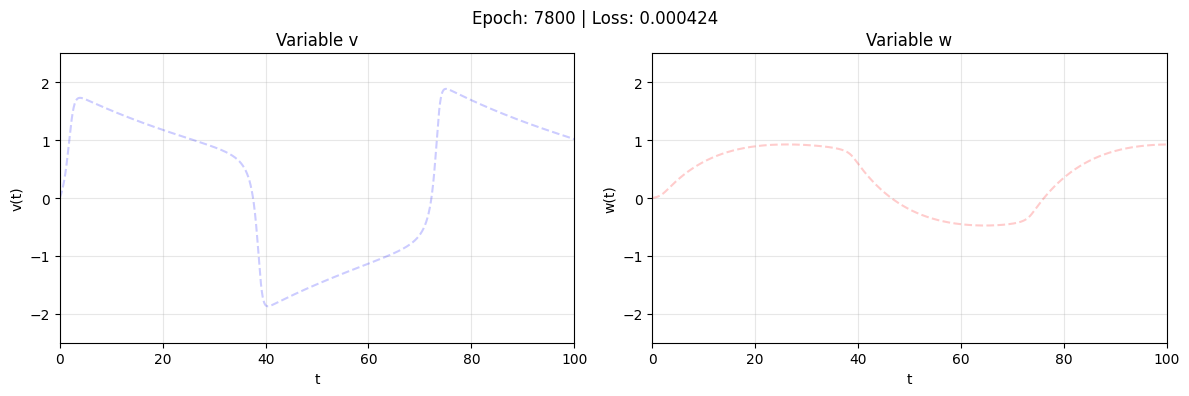

In [104]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

def animar_frames(frames, T=10*T):
    t_np = np.linspace(0, T, Nt)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    line_v, = axes[0].plot([], [], 'b-', lw=2)
    line_vr, = axes[0].plot(t_rk, v_rk,"b--",alpha = 0.2)
    axes[0].set_xlim(0, T)
    axes[0].set_ylim(-2.5, 2.5)
    axes[0].set_xlabel('t')
    axes[0].set_ylabel('v(t)')
    axes[0].set_title('Variable v')
    axes[0].grid(True, alpha=0.3)

    line_w, = axes[1].plot([], [], 'r-', lw=2)
    ine_wr, = axes[1].plot(t_rk, w_rk,"r--",alpha = 0.2)

    axes[1].set_xlim(0, T)
    axes[1].set_ylim(-2.5, 2.5)
    axes[1].set_xlabel('t')
    axes[1].set_ylabel('w(t)')
    axes[1].set_title('Variable w')
    axes[1].grid(True, alpha=0.3)

    epoch_text = fig.suptitle('', fontsize=12)

    def init():
        line_v.set_data([], [])
        line_w.set_data([], [])
        return line_v, line_w

    def update(frame_idx):
        cum_frame_v=np.array([])
        cum_frame_w=np.array([])
        for m in  list(range(frame_idx, len(all_frames), 40)):
          cum_frame_v = np.concatenate([cum_frame_v, all_frames[m]["v"]])
          cum_frame_w = np.concatenate([cum_frame_w, all_frames[m]["w"]])
        f = frames[frame_idx]
        line_v.set_data(t_rk, cum_frame_v)
        line_w.set_data(t_rk, cum_frame_w)
        epoch_text.set_text(f"Epoch: {f['epoch']} | Loss: {f['loss']:.6f}")
        return line_v, line_w

    ani = animation.FuncAnimation(
        fig, update, frames=40,
        init_func=init, interval=100, blit=False
    )

    plt.tight_layout()
    return ani

# uso:
#err, frames = optimizar(model, N=000, N_ode=1000, guardar_cada=100)

ani = animar_frames(all_frames, T=T)
HTML(ani.to_jshtml())


## Diferencia

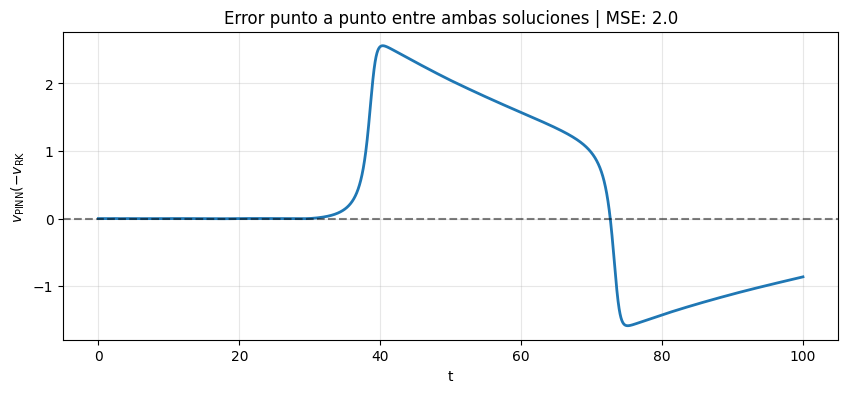

In [105]:
# Diferencia punto a punto
cum_frame=np.array([])
for m in  list(range(39, len(all_frames), 40)):
  cum_frame = np.concatenate([cum_frame, all_frames[m]["v"]])

error = cum_frame - v_rk

plt.figure(figsize=(10,4))
plt.plot(t_rk, error, lw=2)
plt.axhline(0, color='k', ls='--', alpha=0.5)
plt.xlabel("t")
plt.ylabel(r"$v_{\mathrm{PINN}}(-v_{\mathrm{RK}}$")
plt.title(f"Error punto a punto entre ambas soluciones | MSE: {np.round(np.mean(error**2))}")
plt.grid(alpha=0.3)
plt.show()